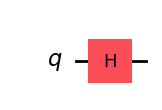

In [2]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(1)
qc.h(0)
qc.draw("mpl")

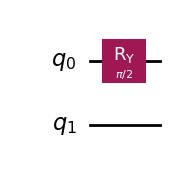

In [3]:
import numpy as np

pi = np.pi

qc = QuantumCircuit(2)
qc.ry(pi / 2, 0)
qc.draw("mpl")

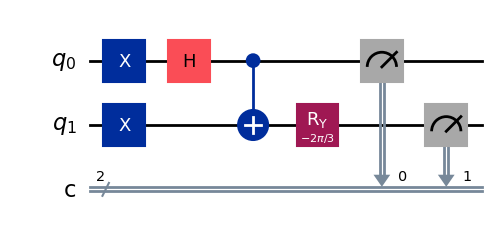

In [4]:
# We'll begin by importing qiskit and a visualization module so that we can plot a histogram of our results.

from qiskit.visualization import plot_histogram

# We start by declaring our first quantum circuit, and giving it two qubits (the first "2") and two classical bits for storing outputs (the second "2")
# Define registers
from qiskit import ClassicalRegister, QuantumRegister

qr = QuantumRegister(2, "q")
cr = ClassicalRegister(2, "c")
qc1 = QuantumCircuit(qr, cr)

# We know from our analysis above that we need an X gate acting on each of the qubits (L and R)
qc1.x([0, 1])
# We need a Hadamard gate acting on Lucas's qubit, which we're calling the 0th qubit.
qc1.h(0)
# The controlled-NOT gate uses the 0th qubit (Lucas's) as the control and the 1st qubit (Rihanna's) as the target.
qc1.cx(0, 1)
# The rotation gate acts on the 1st qubit (Rihanna's) and has an argument of -2 pi/3
qc1.ry(-2 * pi / 3, 1)
# Finally, we want to measure all the qubits in the circuit to obtain measurement probabilities, and store the results in the classical bits.
qc1.measure([0, 1], [0, 1])
# Now we can draw the first of the three circuits that will check Bell's inequality for us.
qc1.draw(output="mpl")

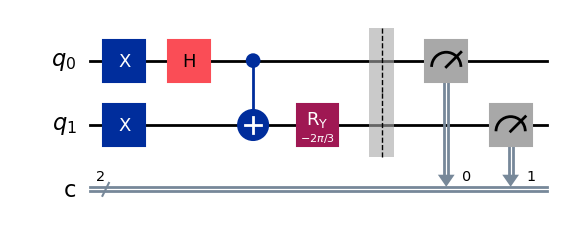

In [7]:
qcs = [QuantumCircuit(2, 2), QuantumCircuit(2, 2), QuantumCircuit(2, 2)]
for i in range(0, len(qcs)):
    qcs[i].x([0, 1])
    qcs[i].h(0)
    qcs[i].cx(0, 1)

qcs[0].ry(-2 * pi / 3, 1)
qcs[1].ry(-4 * pi / 3, 1)
qcs[2].ry(-2 * pi / 3, 1)
qcs[2].ry(-4 * pi / 3, 1)

for i in range(0, len(qcs)):
    qcs[i].barrier()
    qcs[i].measure([0, 1], [0, 1])

counts_list = [None] * len(qcs)
qcs[0].draw(output="mpl")

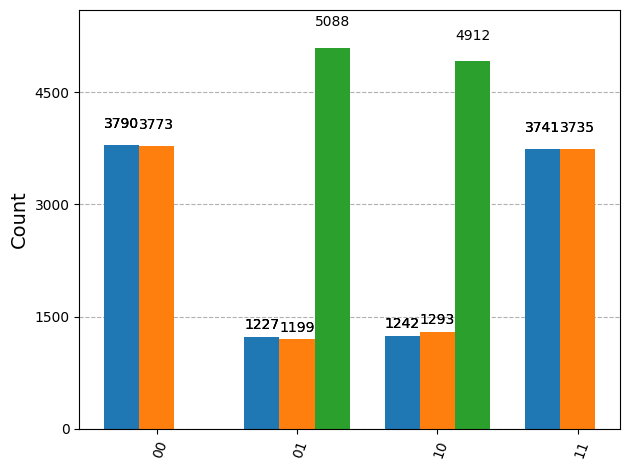

In [8]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

# Start a job that will return shots for all 100 parameter value sets.
for i in range(0, len(qcs)):
    pub = qcs[i]
    job = sampler.run([pub], shots=10000)
    # Extract the result for the 0th pub (this example only has one pub).
    result = job.result()
    data_pub = result[0].data
    counts = data_pub.c.get_counts()
    counts_list[i] = counts
#    plot_histogram(counts)
plot_histogram(counts_list)

{'00': 7563, '01': 7514, '10': 7447, '11': 7476}


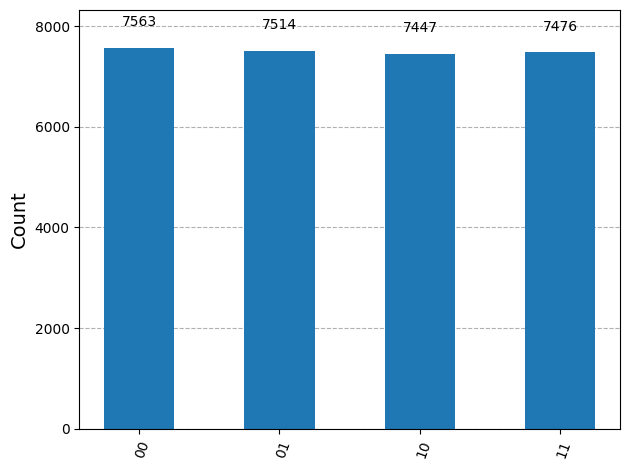

In [9]:
outcomes = ("00", "01", "10", "11")

# Here we convert "None"s into 0's so that we can sum.

for i in range(0, len(qcs)):
    for j in range(0, len(outcomes)):
        if counts_list[i].get(outcomes[j]) is None:
            counts_list[i].update({outcomes[j]: 0})

# Here we create a dictionary that holds all the outcomes and sums over their appearances in each of the circuits.

total_counts = {}
for i in range(0, len(outcomes)):
    total_counts[outcomes[i]] = sum(
        counts_list[j].get(outcomes[i]) for j in range(0, len(qcs))
    )
print(total_counts)
plot_histogram(total_counts)

{'00': 7489, '01': 7468, '10': 7542, '11': 7501}


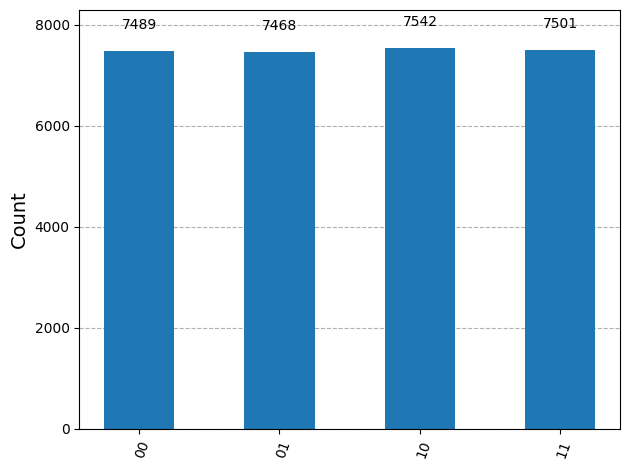

In [15]:
# This syntax allows you to run the job on a simulator, in case you have exhausted your allotted time on real IBM quantum computers.
# But we strongly advise running this on real quantum computers, since this is meant to be a check of the behavior of real quantum systems.

# This uses a local simulator
from qiskit_aer import AerSimulator
from qiskit_aer import AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2 as GB
from qiskit.primitives import BackendSamplerV2 as BS, BackendEstimatorV2 as BE
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

fake_hardware = GB(num_qubits=7)
backend_sim = AerSimulator.from_backend(fake_hardware)

# This generates a simulator that mimics the real quantum system
# backend_sim = AerSimulator.from_backend(backend)

#Import an estimator, this time from qiskit (we import from Runtime for real hardware)
from qiskit.primitives import BackendSamplerV2
sampler = BackendSamplerV2(backend = backend_sim)

pm = generate_preset_pass_manager(target=backend_sim.target, optimization_level=3)
result_list = [None] * len(qcs)
counts_list = [None] * len(qcs)
for i in range(0, len(qcs)):
# Define the primitive unified bloc (pub)
   #pub = qcs[i]
   qc_isa = pm.run(qcs[i])
   job = sampler.run([qc_isa], shots=10000)
# Extract the result for the 0th pub (this example only has one pub).
   result_list[i] = job.result()
   data_pub = result_list[i][0].data    
   counts = data_pub.c.get_counts()
   counts_list[i] = counts

data_pubs = (result_list[0][0].data,result_list[1][0].data,result_list[2][0].data)
outcomes = ("00", "01", "10", "11")

# Here we convert "None"s into 0's so that we can sum.

for i in range(0, len(qcs)):
   for j in range(0, len(outcomes)):
       if counts_list[i].get(outcomes[j]) is None:
           counts_list[i].update({outcomes[j]: 0})

# Here we create a dictionary that holds all the outcomes and sums over their appearances in each of the circuits.

total_counts = {}
for i in range(0, len(outcomes)):
   total_counts[outcomes[i]] = sum(
       counts_list[j].get(outcomes[i]) for j in range(0, len(qcs))
   )

print(total_counts)
plot_histogram(total_counts)